<a href="https://colab.research.google.com/github/rajulaanusree937-hub/task_2_predictive_analysis_using_pyspark_ml/blob/main/task_2_predictive_analysis_using_pyspark_ml_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flight Delay Prediction Using PySpark MLlib

**OBJECTIVE**

The objective of this project is to predict flight delays using machine learning techniques on airline data.

In [9]:
!pip install pyspark

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler

from pyspark.ml.classification import LogisticRegression

from pyspark.ml.evaluation import BinaryClassificationEvaluator

import matplotlib.pyplot as plt

In [11]:
spark = SparkSession.builder \
    .appName("FlightDelayPrediction") \
    .getOrCreate()

In [40]:
df = spark.read.csv(

    "/content/flight_data_2024.csv",

    header=True,

    inferSchema=True
)
print(f"Count after initial CSV load: {df.count()}")

Count after initial CSV load: 4485140


In [13]:
df.show(5)

+----+-----+------------+-----------+----------+-----------------+-----------------+------+----------------+---------------+----+--------------+-------------+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+---------+-----------------+--------+----------------+-------------------+--------+--------+-------------+-------------+---------+--------------+-------------------+
|year|month|day_of_month|day_of_week|   fl_date|op_unique_carrier|op_carrier_fl_num|origin|origin_city_name|origin_state_nm|dest|dest_city_name|dest_state_nm|crs_dep_time|dep_time|dep_delay|taxi_out|wheels_off|wheels_on|taxi_in|crs_arr_time|arr_time|arr_delay|cancelled|cancellation_code|diverted|crs_elapsed_time|actual_elapsed_time|air_time|distance|carrier_delay|weather_delay|nas_delay|security_delay|late_aircraft_delay|
+----+-----+------------+-----------+----------+-----------------+-----------------+------+----------------+---------------+----+--------------+----

In [14]:
df.printSchema()

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- fl_date: date (nullable = true)
 |-- op_unique_carrier: string (nullable = true)
 |-- op_carrier_fl_num: double (nullable = true)
 |-- origin: string (nullable = true)
 |-- origin_city_name: string (nullable = true)
 |-- origin_state_nm: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- dest_city_name: string (nullable = true)
 |-- dest_state_nm: string (nullable = true)
 |-- crs_dep_time: integer (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- taxi_out: double (nullable = true)
 |-- wheels_off: double (nullable = true)
 |-- wheels_on: double (nullable = true)
 |-- taxi_in: double (nullable = true)
 |-- crs_arr_time: integer (nullable = true)
 |-- arr_time: double (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- cancelled: intege

In [15]:
print(df.columns)

['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [31]:
# df = df.dropna()

In [41]:
print(f"Count before adding 'Delayed' column: {df.count()}")
df = df.withColumn(

    "Delayed",

    when(df["dep_delay"] > 15, 1).otherwise(0)
)
print(f"Count after adding 'Delayed' column: {df.count()}")

Count before adding 'Delayed' column: 4485140
Count after adding 'Delayed' column: 4485140


In [42]:
print("--- Schema and Count before select ---")
df.printSchema()
print(f"Count before selecting columns: {df.count()}")
print("--------------------------------------")

selected_columns = [
    "dep_delay",
    "air_time",
    "distance",
    "carrier_delay",
    "weather_delay",
    "late_aircraft_delay",
    "op_unique_carrier", # Changed from "carrier" to "op_unique_carrier"
    "origin",
    "dest",
    "Delayed"
]

df = df.select(selected_columns)
print(f"Count after selecting columns: {df.count()}")

# Fill nulls in numerical feature columns with 0 to prevent row drops
numerical_cols_to_fill = [
    "dep_delay",
    "air_time",
    "distance",
    "carrier_delay",
    "weather_delay",
    "late_aircraft_delay"
]
df = df.fillna(0, subset=numerical_cols_to_fill)
print(f"Count after filling numerical nulls: {df.count()}")

# Fill nulls in string feature columns with "UNKNOWN" to prevent row drops during StringIndexing
string_cols_to_fill = [
    "op_unique_carrier",
    "origin",
    "dest"
]
df = df.fillna("UNKNOWN", subset=string_cols_to_fill)
print(f"Count after filling string nulls: {df.count()}")

--- Schema and Count before select ---
root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- fl_date: date (nullable = true)
 |-- op_unique_carrier: string (nullable = true)
 |-- op_carrier_fl_num: double (nullable = true)
 |-- origin: string (nullable = true)
 |-- origin_city_name: string (nullable = true)
 |-- origin_state_nm: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- dest_city_name: string (nullable = true)
 |-- dest_state_nm: string (nullable = true)
 |-- crs_dep_time: integer (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- taxi_out: double (nullable = true)
 |-- wheels_off: double (nullable = true)
 |-- wheels_on: double (nullable = true)
 |-- taxi_in: double (nullable = true)
 |-- crs_arr_time: integer (nullable = true)
 |-- arr_time: double (nullable = true)
 |-- arr_delay: double (

In [32]:
carrier_indexer = StringIndexer(

    inputCol="op_unique_carrier",

    outputCol="carrier_index",
    handleInvalid="keep"
)

origin_indexer = StringIndexer(

    inputCol="origin",

    outputCol="origin_index",
    handleInvalid="keep"
)

dest_indexer = StringIndexer(

    inputCol="dest",

    outputCol="dest_index",
    handleInvalid="keep"
)

In [49]:
# The column selection and null-filling logic are already handled by VTzvUPR7ePoQ.
# Removing redundant code here to avoid potential issues with DataFrame state.

# Drop existing index columns if they exist to avoid 'Output column already exists' error
columns_to_drop = ["carrier_index", "origin_index", "dest_index"]
df = df.drop(*[col for col in columns_to_drop if col in df.columns])

print(f"DataFrame count before StringIndexing: {df.count()}")
print("df.show(5) before StringIndexing:")
df.show(5)

df = carrier_indexer.fit(df).transform(df)
print(f"DataFrame count after carrier_indexer: {df.count()}")
print("df.show(5) after carrier_indexer:")
df.show(5)

df = origin_indexer.fit(df).transform(df)
print(f"DataFrame count after origin_indexer: {df.count()}")
print("df.show(5) after origin_indexer:")
df.show(5)

df = dest_indexer.fit(df).transform(df)
print(f"DataFrame count after dest_indexer: {df.count()}")
print("df.show(5) after dest_indexer:")
df.show(5)

# Debugging: Check count after all StringIndexing
print(f"DataFrame count after all StringIndexing: {df.count()}")

DataFrame count before StringIndexing: 4485140
df.show(5) before StringIndexing:
+---------+--------+--------+-------------+-------------+-------------------+-----------------+------+----+-------+
|dep_delay|air_time|distance|carrier_delay|weather_delay|late_aircraft_delay|op_unique_carrier|origin|dest|Delayed|
+---------+--------+--------+-------------+-------------+-------------------+-----------------+------+----+-------+
|     -5.0|    84.0|   509.0|            0|            0|                  0|               9E|   JFK| DTW|      0|
|    -14.0|    88.0|   622.0|            0|            0|                  0|               9E|   MSP| CLE|      0|
|     -4.0|    61.0|   288.0|            0|            0|                  0|               9E|   JFK| RIC|      0|
|     -7.0|    51.0|   288.0|            0|            0|                  0|               9E|   RIC| JFK|      0|
|     -5.0|    45.0|   237.0|            0|            0|                  0|               9E|   DTW| MKE|

In [25]:
df.show(5)

+---------+--------+--------+-------------+-------------+-------------------+-----------------+------+----+-------+-------------+------------+----------+
|dep_delay|air_time|distance|carrier_delay|weather_delay|late_aircraft_delay|op_unique_carrier|origin|dest|Delayed|carrier_index|origin_index|dest_index|
+---------+--------+--------+-------------+-------------+-------------------+-----------------+------+----+-------+-------------+------------+----------+
+---------+--------+--------+-------------+-------------+-------------------+-----------------+------+----+-------+-------------+------------+----------+



In [44]:
feature_columns = [

    "dep_delay",
    "air_time",
    "distance",
    "carrier_index",
    "origin_index",
    "dest_index"
]

assembler = VectorAssembler(

    inputCols=feature_columns,

    outputCol="features"
)

data = assembler.transform(df)
print(f"Count after VectorAssembler: {data.count()}")

Count after VectorAssembler: 4485140


In [45]:
final_data = data.select(

    "features",

    "Delayed"
)
print(f"Count of final_data after selection: {final_data.count()}")
print("final_data.show(5) after selection:")
final_data.show(5)

Count of final_data after selection: 4485140
final_data.show(5) after selection:
+--------------------+-------+
|            features|Delayed|
+--------------------+-------+
|[-5.0,84.0,509.0,...|      0|
|[-14.0,88.0,622.0...|      0|
|[-4.0,61.0,288.0,...|      0|
|[-7.0,51.0,288.0,...|      0|
|[-5.0,45.0,237.0,...|      0|
+--------------------+-------+
only showing top 5 rows


In [28]:
final_data.show(5)

+--------+-------+
|features|Delayed|
+--------+-------+
+--------+-------+



In [46]:
train_data, test_data = final_data.randomSplit(

    [0.8, 0.2],

    seed=42
)

print(f"Count of train_data: {train_data.count()}")
print("train_data.show(5):")
train_data.show(5)

print(f"Count of test_data: {test_data.count()}")
print("test_data.show(5):")
test_data.show(5)

Count of train_data: 3587977
train_data.show(5):
+--------------------+-------+
|            features|Delayed|
+--------------------+-------+
|(6,[2,4],[153.0,8...|      0|
|(6,[2,4],[214.0,2...|      0|
|(6,[2,4],[214.0,2...|      0|
|(6,[2,4],[214.0,2...|      0|
|(6,[2,4],[321.0,5...|      0|
+--------------------+-------+
only showing top 5 rows
Count of test_data: 897163
test_data.show(5):
+--------------------+-------+
|            features|Delayed|
+--------------------+-------+
|(6,[2,4],[214.0,2...|      0|
|(6,[2,4],[341.0,1...|      0|
|(6,[2,4],[356.0,3...|      0|
|(6,[2,4],[481.0,7...|      0|
|(6,[2,4],[547.0,1...|      0|
+--------------------+-------+
only showing top 5 rows


In [47]:
print("Distribution of 'Delayed' in train_data:")
train_data.groupBy("Delayed").count().show()

Distribution of 'Delayed' in train_data:
+-------+-------+
|Delayed|  count|
+-------+-------+
|      1| 792802|
|      0|2795175|
+-------+-------+



In [50]:
lr = LogisticRegression(

    featuresCol="features",

    labelCol="Delayed"
)

model = lr.fit(train_data)

In [51]:
predictions = model.transform(test_data)

In [52]:
predictions.select(

    "Delayed",

    "prediction",

    "probability"
).show(10)

+-------+----------+-----------+
|Delayed|prediction|probability|
+-------+----------+-----------+
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
|      0|       0.0|  [1.0,0.0]|
+-------+----------+-----------+
only showing top 10 rows


In [53]:
evaluator = BinaryClassificationEvaluator(

    labelCol="Delayed"
)

accuracy = evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9999994828058715


In [54]:
print(

    "Model Accuracy Percentage:",

    accuracy * 100
)

Model Accuracy Percentage: 99.99994828058715


In [55]:
pred_df = predictions.limit(1000) \
                     .select("prediction") \
                     .toPandas()

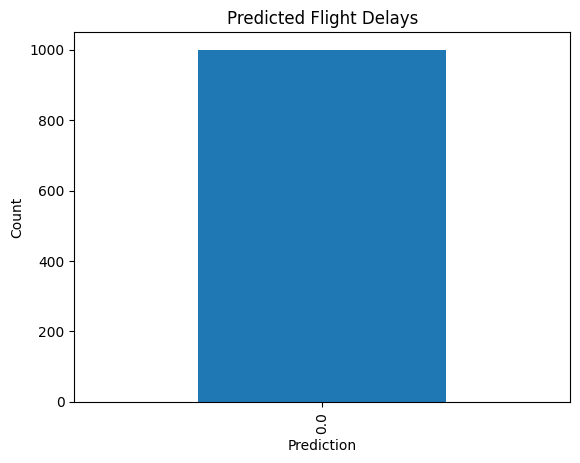

In [56]:
pred_df["prediction"].value_counts().plot(kind="bar")

plt.title("Predicted Flight Delays")

plt.xlabel("Prediction")

plt.ylabel("Count")

plt.show()

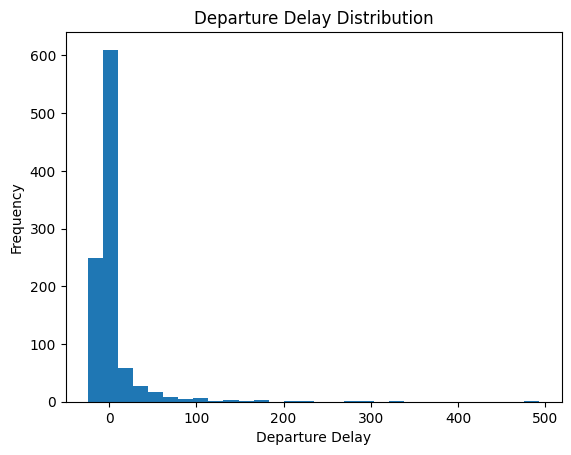

In [57]:
delay_df = df.limit(1000) \
             .select("dep_delay") \
             .toPandas()

plt.hist(delay_df["dep_delay"], bins=30)

plt.title("Departure Delay Distribution")

plt.xlabel("Departure Delay")

plt.ylabel("Frequency")

plt.show()

**INSIGHTS**

1. Flights with higher departure delays are more likely to arrive late.

2. Airline carrier and airport routes affect flight delays.

3. Machine learning successfully predicts delayed flights using historical data.

4. PySpark MLlib efficiently handles large-scale airline datasets.

**CONCLUSION**

This project performed predictive analysis on the Flight Delay Dataset using PySpark MLlib. Logistic Regression was used to classify delayed and non-delayed flights. Data preprocessing, feature engineering, model training, prediction, and evaluation were successfully implemented. The project demonstrated the effectiveness of machine learning in predicting airline delays using big data technologies.
